# QVAE-Mole

Reimplements the core model from [wuhuaijin/QVAE](https://github.com/wuhuaijin/QVAE) — *"QVAE-Mole:
The Quantum VAE with Spherical Latent Variable Learning for 3-D Molecule Generation"* (NeurIPS
2024) — mirroring the structure of `vae.ipynb` / `qvae.ipynb` / `svae.ipynb` (data → model → train →
sample → reconstructions → interpolations).

The official repo is a PyTorch + [TorchQuantum](https://github.com/mit-han-lab/torchquantum)
research codebase (`models/model.py::DrugQAE`, `main.py`, `generate.py`) wired to the QM9 3-D
molecule dataset: it amplitude-encodes each molecule's atom coordinates/types, runs a
hardware-efficient quantum autoencoder, and scores generation with molecule-specific metrics
(validity / bond-length MMD via a focal atom-type loss). TorchQuantum must be cloned from MIT Han
Lab and is not cleanly pip-installable, and the model and losses are tied to the molecule pipeline,
so instead of importing it directly this notebook ports its load-bearing pieces — the RZ-RY-RZ +
ring-CRX hardware-efficient ansatz (`DrugQAE`'s encoder/decoder layers), the
probability-marginalization bottleneck (`DrugQAE.forward`'s reshape/sum over the "bottleneck"
qubits), the von Mises-Fisher spherical-latent sampler (`DrugQAE.sampling_vmf`), and the fidelity
reconstruction objective (`main.py::fidelity_loss`) — as plain `torch` statevector ops, verbatim in
spirit, wired into the same MNIST pipeline used elsewhere in this survey. TorchQuantum already
trains this model with Adam via autograd, so unlike `qvae.ipynb` there is **no** optimizer swap:
every op here (RZ/RY/RX rotations, controlled-RX, amplitude marginalization, vMF tangent-normal
sampling) is differentiable and trained with Adam exactly as in the original.

Unlike a standard VAE — and unlike the maximally-mixed-state regularizer of `qvae.ipynb` — the
latent here lives on a **hypersphere**: the encoder produces a unit vector `mu`, and the
reparameterization draws a sample from a **von Mises-Fisher** distribution `vMF(mu, kappa)`
concentrated around it. The concentration `kappa` plays the role of `beta`: because the
vMF-to-uniform KL depends only on the (fixed) `kappa` it is constant and drops out of the gradient,
so the training objective is reconstruction fidelity alone, with `kappa` controlling how much latent
noise regularizes the encoder.

In [1]:
import math
import pathlib
import sys

import numpy as np
import torch
import torch.nn as nn
import torchvision.datasets as datasets

for _root in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
    if (_root / "vae" / "models").is_dir():
        sys.path.insert(0, str(_root))
        break

from vae.models.qvae_mole import DrugQAE
from vae.handlers.qvae_mole import to_amplitude_states, fidelity_loss, amplitudes_to_image

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_dtype(torch.float64)  # statevector / fidelity math is numerically sensitive

## Data

Same MNIST split used by `vae.ipynb`, amplitude-encoded into pure quantum statevectors. The original
repo amplitude-encodes each molecule's `input_dim`-length feature vector with TorchQuantum's
`AmplitudeEncoder` (`DrugQAE.encoder`); we do the same with MNIST. Simulating dense `n`-qubit
circuits is exponential in the qubit count, so — matching the small feature vectors the original
encodes (QM9 uses `input_dim=73` on `n_qbits=7`) — we downsample each 28x28 image to 8x8=64=2^6
pixels (`n_qbits=6`) and L2-normalize each flattened image to a unit vector. A unit vector is a valid
statevector, and its squared amplitudes are the pixel "probabilities".

In [2]:
mnist_trainset = datasets.MNIST(root='../../data', train=True, download=True, transform=None)

n_qbits = 6
res = 2 ** (n_qbits // 2)  # 8x8 = 64 = 2^6

train_dataset = to_amplitude_states(mnist_trainset.data[:-10000])
eval_dataset = to_amplitude_states(mnist_trainset.data[-10000:])

## Hardware-efficient ansatz (RZ-RY-RZ + ring CRX)

Ported from `DrugQAE`'s encoder/decoder layers in `models/model.py`: `n_blocks + 1` blocks, each a
per-qubit `RZ·RY·RZ` Euler rotation, with a ring of controlled-`RX` gates (qubit `i` controls qubit
`(i+1) % n`) entangling consecutive blocks. TorchQuantum applies these gates to a statevector on a
`QuantumDevice`; here we build the equivalent dense `2^n x 2^n` unitaries (Kronecker products of
single-/two-qubit gates) and apply them to a batch of statevectors as `psi -> U psi`. The decoder
uses an independent parameter set and runs the blocks in reverse (rotation order `RZ·RY·RZ` reversed,
entangler applied before the rotations), matching `DrugQAE`'s decode loop.

## Probability-marginalization bottleneck

Ported from the reshape/sum in `DrugQAE.forward`. After the encoder circuit, the repo reads the
statevector's squared amplitudes (a probability distribution over the `2^n` basis states), reshapes
to `(2^(n - bottleneck), 2^bottleneck)` and sums over the last axis — classically marginalizing out
the `bottleneck_qbits` "trash" qubits — then takes the square root to recover a
`2^(n - bottleneck)`-dimensional amplitude vector. This unit vector is the latent mean `mu`. (It is a
probability marginal, not a quantum partial trace: it discards the kept qubits' phase/coherence,
exactly as the original does.)

## Spherical latent: von Mises-Fisher sampling

The defining novelty of the paper, ported from `DrugQAE.sampling_vmf`. Where a Gaussian VAE draws
`z = mu + sigma * eps`, here the latent lives on the unit hypersphere and the reparameterization
draws `z ~ vMF(mu, kappa)` — the spherical analogue of a Gaussian, concentrated around the encoder's
unit vector `mu` with concentration `kappa`. Sampling uses the standard tangent-normal (Ulrich/Wood)
decomposition: draw the cosine `w` to `mu` from its marginal density
`p(w) ∝ exp(kappa·w)·(1 - w^2)^((d-3)/2)` by inverse-CDF, draw a direction `nu` uniform on the sphere
orthogonal to `mu`, and return `z = w·mu + sqrt(1 - w^2)·nu`. Gradients flow to the encoder through
`mu` (in both `w·mu` and the `nu` projection); the sampling of `w` is the non-differentiable "noise",
like `eps` in the Gaussian trick.

The original rebuilds the inverse-CDF grid on every forward call; since it depends only on `kappa`
and the latent dimension (both fixed), we precompute it once in `__init__` — the same optimization in
spirit as vectorizing the partial trace in `qvae.ipynb`, with the math unchanged.

## Model

`n_qbits = 6` total qubits, with `bottleneck_qbits` (default 2, matching the original's
`--bottleneck_qbits`) marginalized out after the encoder to form the spherical latent of dimension
`2^(n_qbits - bottleneck_qbits) = 16`. The decoder amplitude-encodes the (zero-padded) latent unit
vector back into all `n_qbits` qubits and applies its own reverse ansatz, reading the reconstruction
straight off the output statevector's amplitudes. `n_blocks` sets the ansatz depth (the repo default
is 10; we use 3 here to keep single-CPU simulation snappy, matching the modest budgets of the other
notebooks in this survey).

## Objective: fidelity reconstruction

Ported from `main.py::fidelity_loss`: `1 - <x|recon>^2`, the infidelity of the overlap between the
input statevector and its reconstruction, averaged over the batch. The paper's full molecule loss
adds QM9-specific atom-type / coordinate terms (`loss_func_qm9`); on MNIST amplitudes the bare
fidelity term is the right analogue and is exactly what the repo defines for the reconstruction
objective.

There is no KL / `beta` term: the spherical prior is uniform on the hypersphere, the vMF-to-uniform
KL depends only on the fixed `kappa`, and a constant does not affect the gradient — so `kappa` alone
sets how much the vMF noise regularizes the latent (larger `kappa` = tighter concentration = less
regularization).

In [3]:
model = DrugQAE(n_qbits=n_qbits, n_blocks=3, bottleneck_qbits=2, kappa=20.0).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

num_epochs = 5          # Change this to train the model a bit more
steps_per_epoch = 100   # Change this to train on more data per epoch
batch_size = 32
log_every = 10

train_x = train_dataset.to(device)

for epoch in range(num_epochs):
    epoch_loss = 0.0
    for step in range(steps_per_epoch):
        idx = torch.randint(0, len(train_x), (batch_size,), device=device)
        x = train_x[idx]

        mu, recon = model(x)
        loss = fidelity_loss(x, recon)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

        if (step + 1) % log_every == 0:
            print(f"  epoch {epoch + 1}/{num_epochs}  step {step + 1}/{steps_per_epoch}  "
                  f"fidelity_loss={loss.item():.4f}  mean_fidelity={1 - loss.item():.4f}")

    print(f"epoch {epoch + 1}/{num_epochs}  avg loss={epoch_loss / steps_per_epoch:.4f}")

  epoch 1/5  step 10/100  fidelity_loss=0.9140  mean_fidelity=0.0860


  epoch 1/5  step 20/100  fidelity_loss=0.8331  mean_fidelity=0.1669


  epoch 1/5  step 30/100  fidelity_loss=0.7429  mean_fidelity=0.2571


  epoch 1/5  step 40/100  fidelity_loss=0.6893  mean_fidelity=0.3107


  epoch 1/5  step 50/100  fidelity_loss=0.6717  mean_fidelity=0.3283


...

  epoch 5/5  step 60/100  fidelity_loss=0.5422  mean_fidelity=0.4578


  epoch 5/5  step 70/100  fidelity_loss=0.5507  mean_fidelity=0.4493


  epoch 5/5  step 80/100  fidelity_loss=0.5752  mean_fidelity=0.4248


  epoch 5/5  step 90/100  fidelity_loss=0.5771  mean_fidelity=0.4229


  epoch 5/5  step 100/100  fidelity_loss=0.5562  mean_fidelity=0.4438
epoch 5/5  avg loss=0.5524


## Visualizing samples

The original samples molecules by drawing a random latent and running only the decoder
(`main.py::generate`: `z = |N(0, I)|`, normalized onto the unit sphere, then `model.generate(z)`). We
do the same here — a random non-negative unit vector on the latent hypersphere, decoded to an image
— the spherical-prior analogue of `NormalSampler` in `vae.ipynb`.

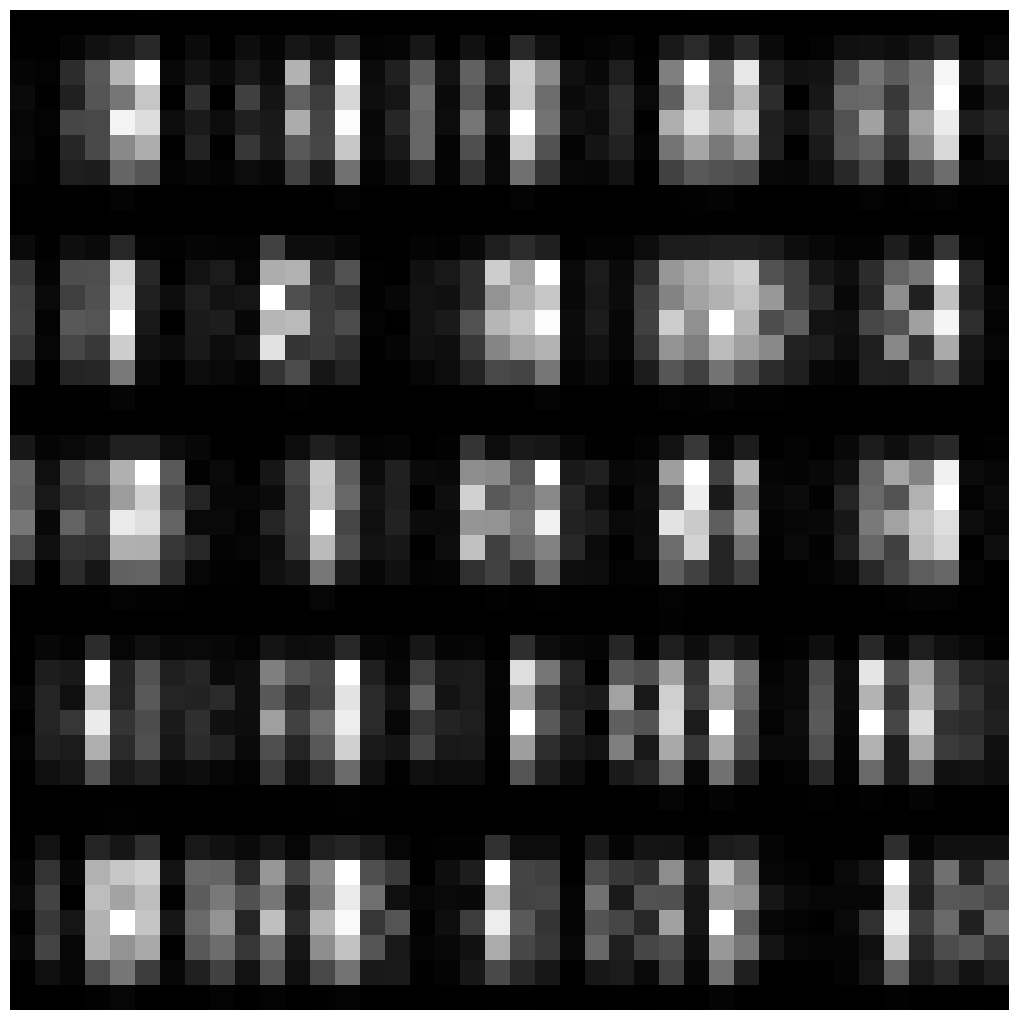

In [4]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    z = torch.randn(25, model.latent_dim, device=device).abs()   # main.py::generate draws |N(0, I)|
    z = z / z.norm(dim=1, keepdim=True)
    gen_data = amplitudes_to_image(model.decode(z)).cpu()

fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(10, 10))
for i in range(5):
    for j in range(5):
        axes[i][j].imshow(gen_data[i * 5 + j], cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)

## Visualizing reconstructions

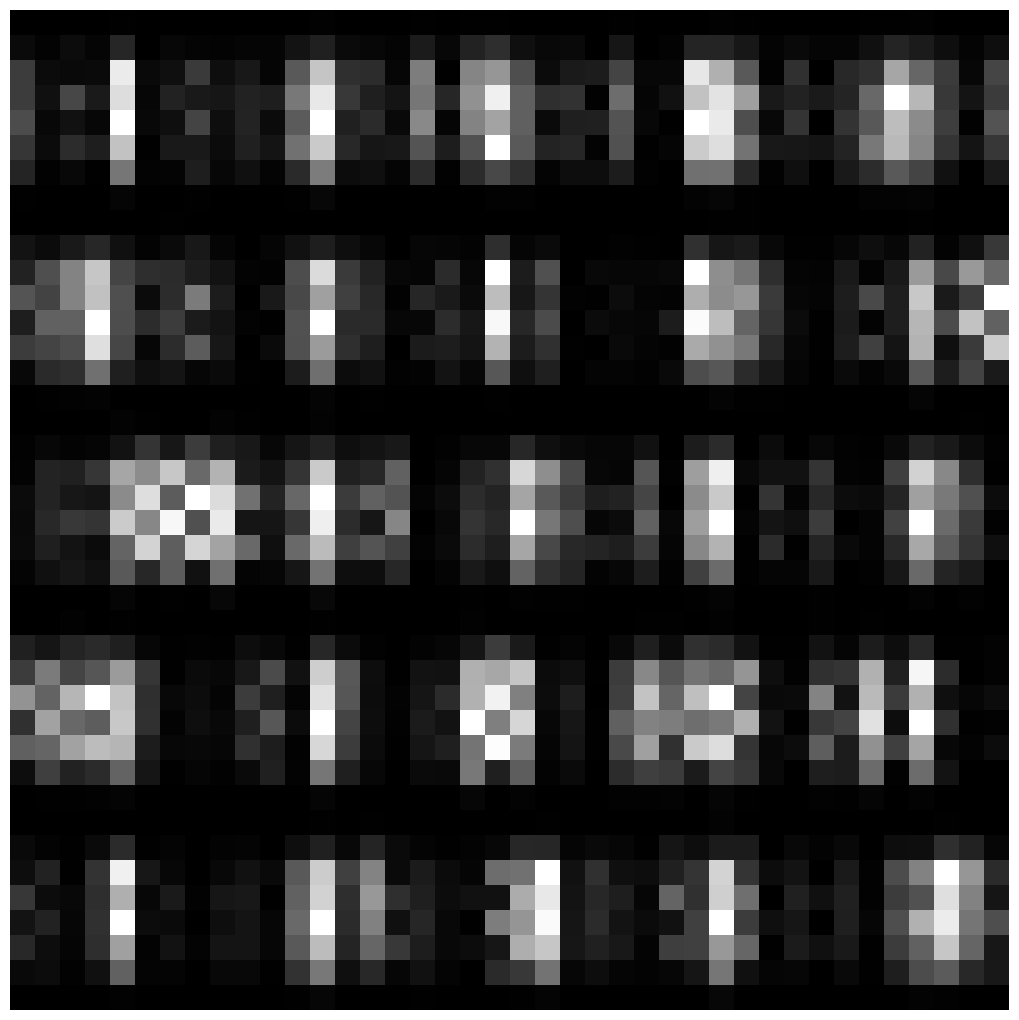

In [5]:
eval_x = eval_dataset[:25].to(device)
with torch.no_grad():
    _, recon = model(eval_x)
    reconstructions = amplitudes_to_image(recon).cpu()

fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(10, 10))
for i in range(5):
    for j in range(5):
        axes[i][j].imshow(reconstructions[i * 5 + j], cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)

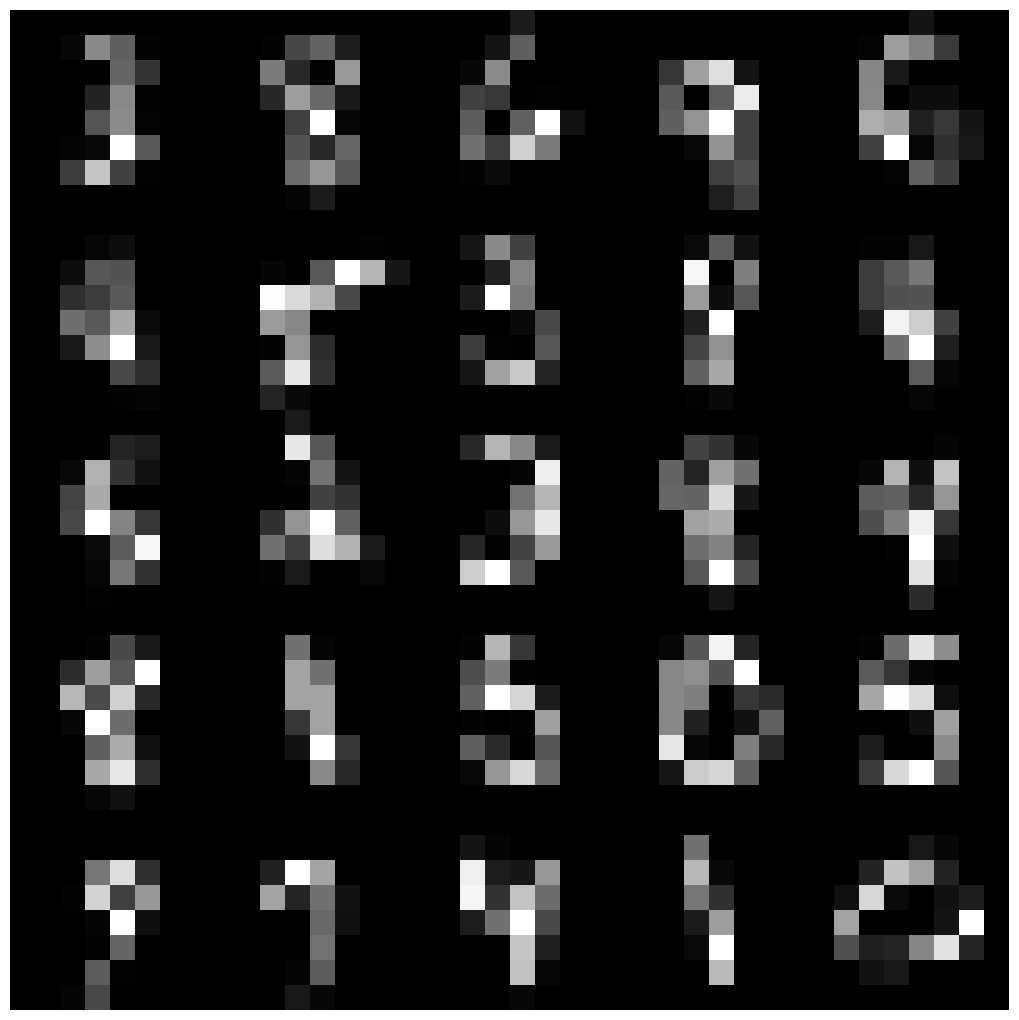

In [6]:
# show the true data
true_images = (eval_x.cpu() ** 2).reshape(-1, res, res)  # amplitudes^2 = pixel probabilities

fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(10, 10))
for i in range(5):
    for j in range(5):
        axes[i][j].imshow(true_images[i * 5 + j], cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)

## Visualizing interpolations

Because the latent lives on a hypersphere, the natural analogue of the straight-line latent
interpolation in `vae.ipynb` is **spherical linear interpolation (slerp)** between two encoded latent
unit vectors — staying on the sphere the vMF prior is defined over — decoded at each step.

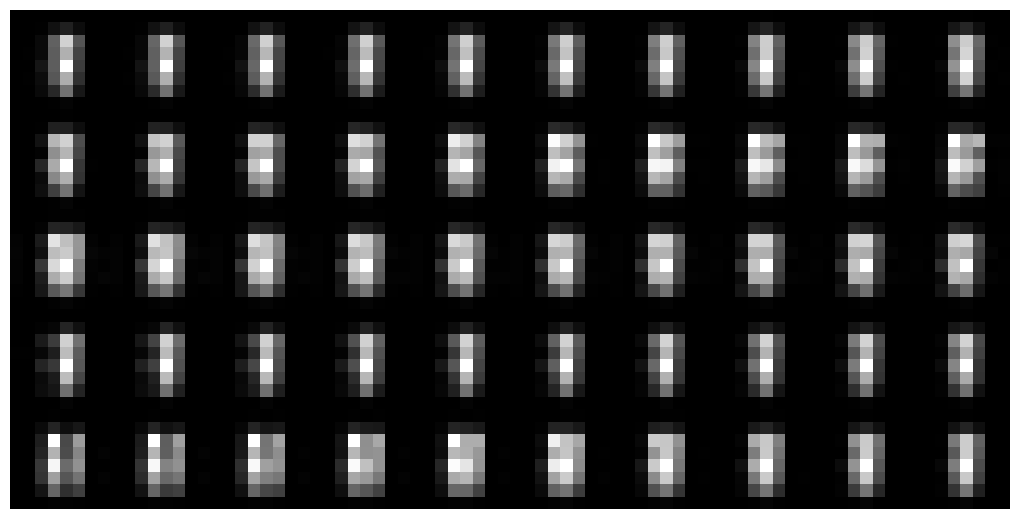

In [7]:
x1 = eval_dataset[:5].to(device)
x2 = eval_dataset[5:10].to(device)

with torch.no_grad():
    z1, z2 = model.encode(x1), model.encode(x2)
    dot = (nn.functional.normalize(z1, dim=1) * nn.functional.normalize(z2, dim=1)).sum(1, keepdim=True).clamp(-1, 1)
    omega = torch.acos(dot)
    sin_omega = torch.sin(omega)

    granularity = 10
    frames = []
    for a in torch.linspace(0, 1, granularity, device=device):
        z = torch.where(sin_omega.abs() < 1e-6,
                        (1 - a) * z1 + a * z2,
                        (torch.sin((1 - a) * omega) / sin_omega) * z1 + (torch.sin(a * omega) / sin_omega) * z2)
        frames.append(model.decode(z))
    interpolations = torch.stack(frames)  # (granularity, 5, 2^n)
    interpolations = amplitudes_to_image(interpolations.reshape(-1, interpolations.shape[-1]))
    interpolations = interpolations.reshape(granularity, 5, res, res).permute(1, 0, 2, 3).cpu()

fig, axes = plt.subplots(nrows=5, ncols=10, figsize=(10, 5))
for i in range(5):
    for j in range(10):
        axes[i][j].imshow(interpolations[i, j], cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)